---

## title: Interactive Spectra Scrolling Widget

In [1]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
plt.rcParams["figure.dpi"] = 150

When working with dynamic Magnetic Resonance Spectroscopy (MRS) or Magnetic Resonance Imaging (MRI) data, you rarely deal with a single spectrum. Whether you are tracking a dynamic metabolic timecourse, inspecting multi-echo $T_2$ relaxation data, or looking for motion artifacts across hundreds of transient averages, visualizing 2D datasets is a constant challenge.

Plotting 50 overlaid spectra on a static matplotlib axis quickly becomes an unreadable mess of overlapping lines.

To solve this, `xmris` provides an interactive, browser-based `ScrollWidget`. It allows you to fluidly scroll through multidimensional data, animate the transitions, visualize fading historical traces to see trends, and—most importantly—extract specific slices directly into reproducible code.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import xmris


## 1. Generating a 2D Time Series

Let's generate a synthetic 2D dataset representing 50 transient repetitions. We will simulate a decaying signal (e.g., relaxation) and inject a massive motion artifact at repetition #25.

In [3]:
# Generate synthetic 2D data
n_reps = 50
n_points = 1024
ppm = np.linspace(10, -2, n_points)
repetitions = np.arange(n_reps)

# Simulate a decaying peak at 4.7 ppm (Water) and a stable peak at 2.0 ppm (NAA)
ppm_mesh, rep_mesh = np.meshgrid(ppm, repetitions)

# Peak 1: Decaying
peak_water = 10.0 * np.exp(-rep_mesh / 15.0) / (1 + ((ppm_mesh - 4.7) / 0.1)**2)
# Peak 2: Stable
peak_naa = 3.0 / (1 + ((ppm_mesh - 2.0) / 0.05)**2)

clean_data = peak_water + peak_naa

rng = np.random.default_rng(42)
noise = rng.normal(scale=0.2, size=(n_reps, n_points))
data_2d = clean_data + noise

# Inject an artifact at index 25
data_2d[25, :] += 5.0 * np.sin(2 * np.pi * 5 * ppm)

# Build the xarray DataArray
da_series = xr.DataArray(
    data_2d,
    dims=["repetitions", "ppm"],
    coords={"repetitions": repetitions, "ppm": ppm},
    attrs={"xmris_synthetic": True}
)

## 2. Launching the Widget

You can launch the interactive viewer directly from the `.xmr.widget` accessor. Pass your 2D `DataArray` to the `scroll_spectra` function.

The widget will automatically detect your spectral dimension (e.g., `ppm`) and assign the remaining dimension (e.g., `repetitions`) to the scroll wheel.

In [4]:
# Launch the interactive widget
da_series.xmr.widget.scroll_spectra(show_trace=True, trace_count=5)

### Using the Widget

Once rendered in your notebook, you can interact with the dataset using the following controls:

* **Mouse Wheel:** Hover over the canvas and scroll up/down to seamlessly step through the repetitions.
* **Keyboard Navigation:** Use the `Left`/`Right` arrow keys to step, or `Home`/`End` to jump to the boundaries.
* **Playback:** Click the `▶` button (or press the `Spacebar`) to animate the sequence automatically. This is incredibly useful for spotting transient motion artifacts that flash on screen.
* **History Trails:** Toggle the "History Trails" checkbox and adjust the "Depth" slider to show fading previous traces (in lighter blue) behind the active trace. This provides instant visual context for signal decay or growth.

## 3. Extracting a Target Slice

While scrolling, you will likely notice the massive artifact we injected halfway through the acquisition.

Interactive widgets are excellent for *finding* these bad transients, but to remove or process them, you need to bring that knowledge back into your Python pipeline. `xmris` strictly enforces data lineage, meaning we do not want the widget to modify the array behind the scenes.

When you locate the artifact (index 25), click the **Extract Slice** button in the widget control bar. The canvas will unmount and provide you with the exact xarray command needed to isolate that trace.

Click the **Copy Code** button, and paste it into the next cell in your notebook:

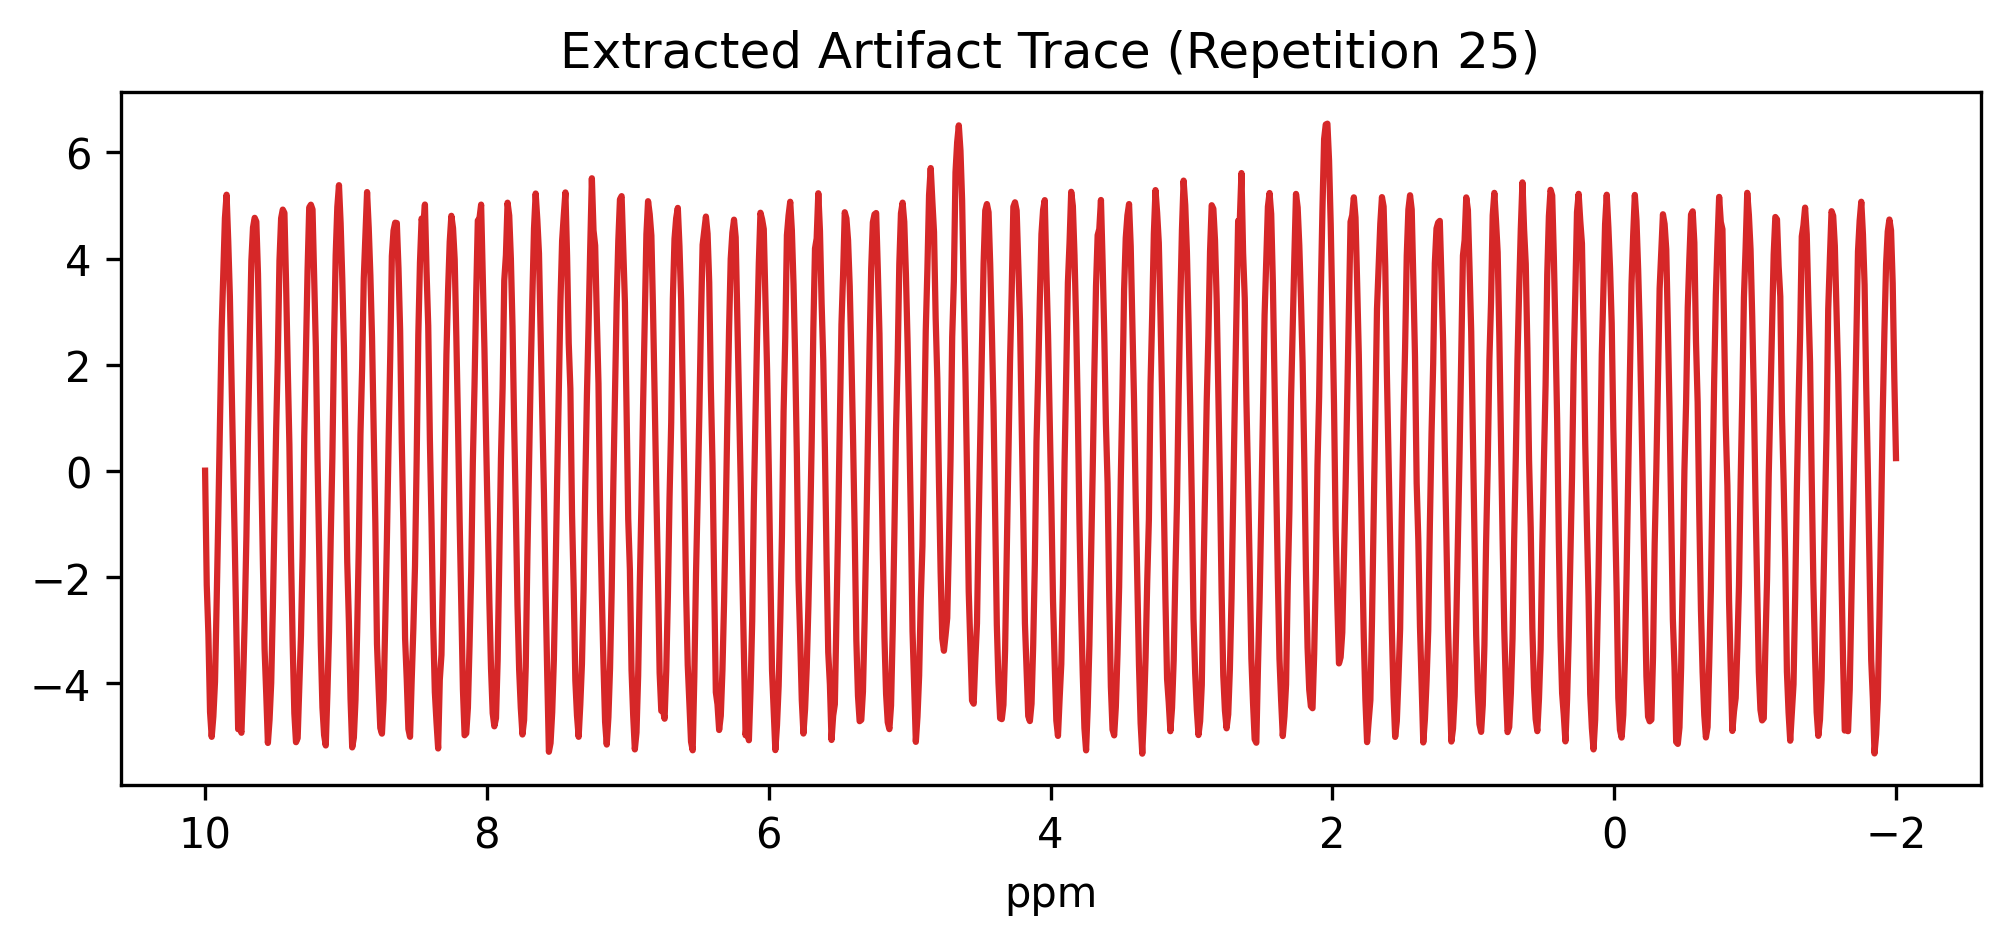

In [5]:
# This code is pasted directly from the widget's completion screen!
slice_da = da_series.isel(repetitions=25)

# Verify the artifact
fig, ax = plt.subplots(figsize=(8, 3))
slice_da.plot(ax=ax, color="tab:red")
plt.title("Extracted Artifact Trace (Repetition 25)")
plt.gca().invert_xaxis() # High ppm on the left
plt.show()


Because the widget generates standard `xarray.isel()` commands, your extracted `slice_da` perfectly retains all coordinates, named dimensions, and `.attrs` from the parent dataset. Your metadata lineage remains unbroken.

In [6]:
# STRICT TESTS: Widget Output Integration
assert slice_da.ndim == 1, "Extracted slice should be 1-dimensional."
assert "ppm" in slice_da.dims, "Spectral dimension was lost during extraction."
assert "xmris_synthetic" in slice_da.attrs, "Lineage attributes were lost."

# Mathematically prove the data matches the injected artifact at index 25
np.testing.assert_allclose(
    slice_da.values,
    data_2d[25, :],
    rtol=1e-5,
    atol=1e-5,
    err_msg="Extracted slice data does not match the expected underlying matrix row."
)